In [2]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
load_dotenv()

True

In [4]:
model = ChatOpenAI(model = 'gpt-5-nano')

In [6]:
class ChatState(MessagesState):
    summary: str

In [7]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n {state['summary']}"
        })

    messages.extend(state['messages'])
    print(messages)
    response = model.invoke(messages)
    return {"messages": [response]}

In [8]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [9]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [10]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [11]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

In [12]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

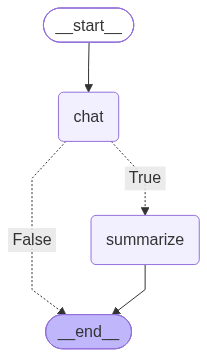

In [13]:
graph

In [14]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [15]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [16]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='83ee9c70-f993-4a03-a3a0-769dfd587ebe')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Nice topic. Do you want a broad primer or something specific? Here’s a quick ove


In [17]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='83ee9c70-f993-4a03-a3a0-769dfd587ebe'), AIMessage(content="Nice topic. Do you want a broad primer or something specific? Here’s a quick overview to ground us, plus options for deeper dives.\n\nWhat quantum physics is (in brief)\n- Describes nature at the smallest scales (atoms, photons, electrons).\n- Wave-particle duality: entities show both particle-like and wave-like properties.\n- Quantum states and probabilities: systems are described by a wavefunction, and only probabilities of outcomes are predicted.\n- Superposition: systems can be in combinations of states until measured.\n- Entanglement: distant systems can have correlated properties that defy classical explanation.\n- Measurement and reality: measurement affects the system; the act of observation plays a special role.\n- Mathematical backbone: Hilbert spaces, operators, eigenvalues, and the Schrödinger equation govern dynamics.\n- Uncert

In [18]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='83ee9c70-f993-4a03-a3a0-769dfd587ebe'), AIMessage(content="Nice topic. Do you want a broad primer or something specific? Here’s a quick overview to ground us, plus options for deeper dives.\n\nWhat quantum physics is (in brief)\n- Describes nature at the smallest scales (atoms, photons, electrons).\n- Wave-particle duality: entities show both particle-like and wave-like properties.\n- Quantum states and probabilities: systems are described by a wavefunction, and only probabilities of outcomes are predicted.\n- Superposition: systems can be in combinations of states until measured.\n- Entanglement: distant systems can have correlated properties that defy classical explanation.\n- Measurement and reality: measurement affects the system; the act of observation plays a special role.\n- Mathematical backbone: Hilbert spaces, operators, eigenvalues, and the Schrödinger equation govern dynamics.\n- Uncert

In [19]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='83ee9c70-f993-4a03-a3a0-769dfd587ebe'), AIMessage(content="Nice topic. Do you want a broad primer or something specific? Here’s a quick overview to ground us, plus options for deeper dives.\n\nWhat quantum physics is (in brief)\n- Describes nature at the smallest scales (atoms, photons, electrons).\n- Wave-particle duality: entities show both particle-like and wave-like properties.\n- Quantum states and probabilities: systems are described by a wavefunction, and only probabilities of outcomes are predicted.\n- Superposition: systems can be in combinations of states until measured.\n- Entanglement: distant systems can have correlated properties that defy classical explanation.\n- Measurement and reality: measurement affects the system; the act of observation plays a special role.\n- Mathematical backbone: Hilbert spaces, operators, eigenvalues, and the Schrödinger equation govern dynamics.\n- Uncert